In [2]:
# ============================================================
# LESSON 13 — PCA (PRINCIPAL COMPONENT ANALYSIS)
# Complete Example
# ============================================================

# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ============================================================
# 2. LOAD DATASET
# ============================================================

wine = load_wine()

X = wine.data
y = wine.target

print("Original shape of X:", X.shape)
print("Target shape:", y.shape)




Original shape of X: (178, 13)
Target shape: (178,)


In [3]:
# ============================================================
# 3. FEATURE NAMES
# ============================================================

print("\nFeatures:")
print(wine.feature_names)


# ============================================================
# 4. FEATURE SCALING
# ============================================================
# PCA is affected by feature scale.
# So we standardize the features first.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled data shape:", X_scaled.shape)





Features:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Scaled data shape: (178, 13)


In [4]:
# ============================================================
# 5. APPLY PCA WITH 2 COMPONENTS
# ============================================================
# Original dataset has 13 features.
# We reduce it to only 2 features.

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA data shape:", X_pca.shape)


# ============================================================
# 6. VIEW THE TRANSFORMED DATA
# ============================================================

print("\nFirst 5 PCA rows:")
print(X_pca[:5])





PCA data shape: (178, 2)

First 5 PCA rows:
[[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 [ 3.75706561  2.75637191]
 [ 1.00890849  0.86983082]]


In [5]:
# ============================================================
# 7. EXPLAINED VARIANCE RATIO
# ============================================================
# Shows how much variance each principal component explains.

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)





Explained Variance Ratio:
[0.36198848 0.1920749 ]


In [6]:
# ============================================================
# 8. TOTAL VARIANCE RETAINED
# ============================================================

total_variance = pca.explained_variance_ratio_.sum()

print("\nTotal variance retained:")
print(total_variance)

print("\nTotal variance retained (%):")
print(total_variance * 100)





Total variance retained:
0.5540633835693527

Total variance retained (%):
55.40633835693527


In [7]:
# ============================================================
# 9. PRINCIPAL COMPONENTS
# ============================================================
# Shows how original features contribute to each component.

print("\nPrincipal Components:")
print(pca.components_)





Principal Components:
[[ 0.1443294  -0.24518758 -0.00205106 -0.23932041  0.14199204  0.39466085
   0.4229343  -0.2985331   0.31342949 -0.0886167   0.29671456  0.37616741
   0.28675223]
 [ 0.48365155  0.22493093  0.31606881 -0.0105905   0.299634    0.06503951
  -0.00335981  0.02877949  0.03930172  0.52999567 -0.27923515 -0.16449619
   0.36490283]]


In [8]:
# ============================================================
# 10. COMPONENT SHAPE
# ============================================================

print("\nShape of principal components:")
print(pca.components_.shape)





Shape of principal components:
(2, 13)


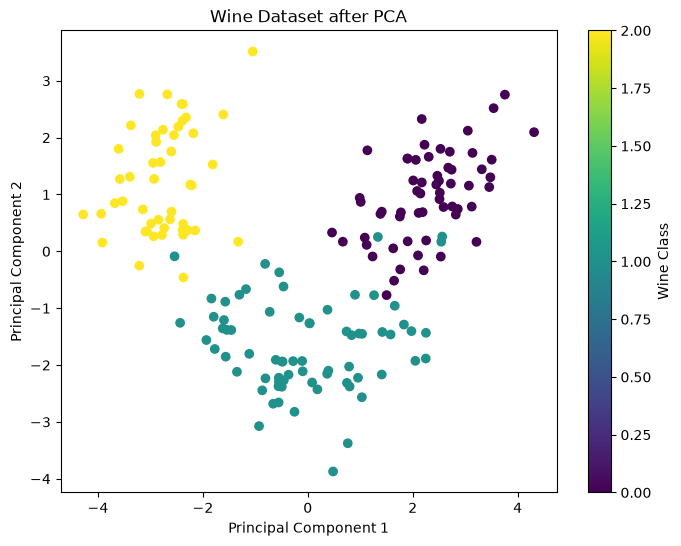

In [9]:
# ============================================================
# 11. VISUALIZE PCA RESULT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Wine Dataset after PCA")

plt.colorbar(label="Wine Class")

plt.show()




In [10]:
# ============================================================
# 12. CUMULATIVE EXPLAINED VARIANCE
# ============================================================
# To decide how many components we should keep,
# calculate PCA using ALL components.

pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

print("\nExplained variance of all components:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)





Explained variance of all components:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Cumulative explained variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


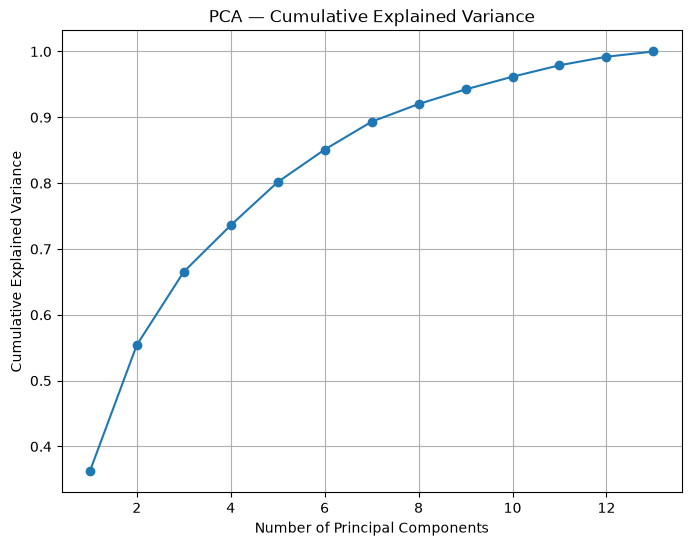

In [11]:
# ============================================================
# 13. PLOT CUMULATIVE EXPLAINED VARIANCE
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA — Cumulative Explained Variance")

plt.grid()

plt.show()




In [12]:
# ============================================================
# 14. FIND NUMBER OF COMPONENTS FOR 95% VARIANCE
# ============================================================

components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("\nComponents required to retain at least 95% variance:")
print(components_95)


# ============================================================
# 15. PCA USING 95% VARIANCE
# ============================================================
# Instead of manually choosing the number,
# PCA can automatically keep enough components
# to preserve 95% variance.

pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("\nOriginal shape:")
print(X.shape)

print("\nShape after PCA with 95% variance:")
print(X_pca_95.shape)

print("\nActual number of components:")
print(pca_95.n_components_)

print("\nVariance retained:")
print(pca_95.explained_variance_ratio_.sum())





Components required to retain at least 95% variance:
10

Original shape:
(178, 13)

Shape after PCA with 95% variance:
(178, 10)

Actual number of components:
10

Variance retained:
0.9616971684450644


In [13]:
# ============================================================
# 16. PCA COMPONENTS
# ============================================================

print("\nPCA Components:")
print(pca_95.components_)





PCA Components:
[[ 0.1443294  -0.24518758 -0.00205106 -0.23932041  0.14199204  0.39466085
   0.4229343  -0.2985331   0.31342949 -0.0886167   0.29671456  0.37616741
   0.28675223]
 [ 0.48365155  0.22493093  0.31606881 -0.0105905   0.299634    0.06503951
  -0.00335981  0.02877949  0.03930172  0.52999567 -0.27923515 -0.16449619
   0.36490283]
 [-0.20738262  0.08901289  0.6262239   0.61208035  0.13075693  0.14617896
   0.1506819   0.17036816  0.14945431 -0.13730621  0.08522192  0.16600459
  -0.12674592]
 [-0.0178563   0.53689028 -0.21417556  0.06085941 -0.35179658  0.19806835
   0.15229479 -0.20330102  0.39905653  0.06592568 -0.42777141  0.18412074
  -0.23207086]
 [-0.26566365  0.03521363 -0.14302547  0.06610294  0.72704851 -0.14931841
  -0.10902584 -0.50070298  0.13685982 -0.07643678 -0.17361452 -0.10116099
  -0.1578688 ]
 [ 0.21353865  0.53681385  0.15447466 -0.10082451  0.03814394 -0.0841223
  -0.01892002 -0.25859401 -0.53379539 -0.41864414  0.10598274  0.26585107
   0.11972557]
 [-0.0

In [14]:
# ============================================================
# 17. RECONSTRUCTION
# ============================================================
# PCA can approximately reconstruct the original data
# from the reduced representation.

pca_reconstruction = PCA(n_components=2)

X_reduced = pca_reconstruction.fit_transform(X_scaled)

X_reconstructed = pca_reconstruction.inverse_transform(X_reduced)

print("\nOriginal scaled data shape:")
print(X_scaled.shape)

print("\nReduced data shape:")
print(X_reduced.shape)

print("\nReconstructed data shape:")
print(X_reconstructed.shape)





Original scaled data shape:
(178, 13)

Reduced data shape:
(178, 2)

Reconstructed data shape:
(178, 13)


In [15]:
# ============================================================
# 18. COMPARE ORIGINAL AND RECONSTRUCTED DATA
# ============================================================

print("\nOriginal first row:")
print(X_scaled[0])

print("\nReconstructed first row:")
print(X_reconstructed[0])


# ============================================================
# 19. COMPLETE PCA PIPELINE
# ============================================================
# The basic workflow you should remember:

print("""
============================================================
PCA WORKFLOW
============================================================

Original Data
      |
      v
StandardScaler
      |
      v
Scaled Data
      |
      v
PCA
      |
      v
Reduced Dimensions
      |
      v
Visualization / ML Model

============================================================
""")


Original first row:
[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
  1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
  1.01300893]

Reconstructed first row:
[ 1.17683758 -0.48854671  0.44943066 -0.80905314  0.90346271  1.40287378
  1.39791791 -0.9486178   1.09629808  0.47110942  0.58106277  1.01020946
  1.47780928]

PCA WORKFLOW

Original Data
      |
      v
StandardScaler
      |
      v
Scaled Data
      |
      v
PCA
      |
      v
Reduced Dimensions
      |
      v
Visualization / ML Model


